In [1]:
import dask
from dask.distributed import Client
from dask.distributed import SSHCluster
from dask.distributed import LocalCluster 
from dask.delayed import delayed
import dask.dataframe as dd 
import dask.array as da
import dask.bag as d
import graphviz

import pandas as pd
import numpy as np
import itertools
from time import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as patches
warnings.filterwarnings("ignore")

In [2]:
n_workers = 2
nthreads  = 2


cluster = SSHCluster(
    ["10.67.22.48", "10.67.22.48", "10.67.22.229", "10.67.22.45"],
    worker_options={"nthreads": nthreads, "n_workers": n_workers},
    scheduler_options={"port":0, "dashboard_address": ":40973"},
    connect_options={
    "known_hosts": None,
    "client_keys": "cluster_key"})

#client = Client(cluster, timeout='60s')
client = Client(cluster,'dask-scheduler:8787')


2025-08-22 12:37:49,371 - distributed.deploy.ssh - INFO - /home/ubuntu/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 40973 is already in use.
2025-08-22 12:37:49,373 - distributed.deploy.ssh - INFO - Perhaps you already have a cluster running?
2025-08-22 12:37:49,373 - distributed.deploy.ssh - INFO - Hosting the HTTP server on port 44175 instead
2025-08-22 12:37:49,373 - distributed.deploy.ssh - INFO - warnings.warn(
2025-08-22 12:37:49,399 - distributed.deploy.ssh - INFO - 2025-08-22 12:37:49,399 - distributed.scheduler - INFO - State start
2025-08-22 12:37:49,400 - distributed.deploy.ssh - INFO - 2025-08-22 12:37:49,400 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-vivsis3n', purging
2025-08-22 12:37:49,401 - distributed.deploy.ssh - INFO - 2025-08-22 12:37:49,400 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-1xabimhy', purging
2025-08-22 12:3

In [3]:
client

<Client: 'tcp://10.67.22.48:42499' processes=5 threads=10, memory=19.43 GiB>

In [4]:
print(client.dashboard_link)
print(client.scheduler_info()["address"])
print(client.scheduler_info()["services"])

http://10.67.22.48:44175/status
tcp://10.67.22.48:42499
{'dashboard': 44175}


In [5]:
client.scheduler_info()['workers'].keys()

dict_keys(['tcp://10.67.22.229:34447', 'tcp://10.67.22.229:46067', 'tcp://10.67.22.45:35293', 'tcp://10.67.22.45:38009', 'tcp://10.67.22.48:37241'])

In [5]:
## >> xx selects rotates bits to the right by xx places
@dask.delayed
def bites_converter(block): 
    # organize in numpy arrays of 64 bits
    byte_array = np.frombuffer(block, dtype=np.uint64)
    
    # bit masking
    head = (byte_array >> 61) & 0x7         # select bits 61–63 (3 bits)
    fpga = (byte_array >> 58) & 0x7         # select bits 58–60 (3 bits)
    chan = (byte_array >> 49) & 0x1FF       # select bits 49–57 (9 bits)
    orbit = (byte_array >> 17) & 0xFFFFFFFF  # select bits 17–48 (32 bits)
    bx = (byte_array >> 5) & 0xFFF        # select bits 5–16 (12 bits)
    tdc = (byte_array >> 0) & 0x1F         # select bits 0–4 (5 bits)
    
    # we are only interested in data with head==2 
    df = pd.DataFrame(
    {"FPGA": fpga[head==2],
    "CHAN": chan[head==2],
    "ORBIT": orbit[head==2],
    "BX": bx[head==2],
    "TDC": tdc[head==2]} )
    
    return(df)

In [6]:

def read_file(file):

    client_kwargs={
        "endpoint_url": "https://cloud-areapd.pd.infn.it:5210", "verify": False}

    # small is a small bytes object from the start of the first file (to infer format), block is a list of Dask delayed objects, representing chunks of bytes from a file
    small, blocks = dask.bytes.read_bytes(
            file,
            key="32b22133696b4aad9a2872435d392277",
            secret="d2111717321d4f7dbd6755b98e95e713",
            client_kwargs=client_kwargs)  
    
    dfs = [dask.delayed(bites_converter)(block[0]) for block in blocks] # apply converter to each block lazily (each block object is a tuple, so i select [0])
    # converts a list of Dask delayed objects (chunks of a DataFrame) into a unique Dask DataFrame
    ddf = dd.from_delayed(dfs)
    return(ddf)

In [7]:
# This fuction:
# - filters events with a single scintillator hit per orbit (in order to be able to identify a unique t_0)
# - assigns the chamber number to each event
# - consider only events with more than 4 and less than num_hits chamber hits per orbit (4 are usually needed to pass the 4 detector layers, if less it is very likely noise) 
# - calculates relative time between the chamber hits and the scintillator hits to determine the drift time
#@dask.delayed
def first_processing(df,num_hits):
    
    # select scintillator hits
    scintillator = df[(df["FPGA"]==1) & (df["CHAN"]==128)].copy()
    scintillator = scintillator[["ORBIT", "BX", "TDC"]]
    scintillator["t_0"] = 25*(scintillator["ORBIT"]*3564 + scintillator["BX"] + scintillator["TDC"]/30)

    # count scintillator hits per ORBIT
    scint_counts = scintillator.groupby("ORBIT").size().to_frame("scint_hits").reset_index()
    # keep only ORBITs with a single scintillator hit
    valid_orbits = scint_counts[scint_counts["scint_hits"] == 1]["ORBIT"]
    
 
    df = df[df["CHAN"]<=127] # remove info about the scintillator

    # assign chamber number
    df = df.assign(CHAMBER = -1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] <= 63), 0)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] > 63), 1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] <= 63), 2)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] > 63), 3)

    # scintilattor time offset correction, per chamber
    df = df.assign(time_offset = 0.0)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 0, 95.0-1.1)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 1, 95.0+6.4)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 2, 95.0+0.5)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 3, 95.0-2.6)
    
    df["T_HIT"] = 25*(df["ORBIT"]*3564 + df["BX"] + df["TDC"]/30)
    
    # filter scintillator hits and main df: keep only events with 1 scintillator hit per ORBIT
    scintillator = scintillator[scintillator["ORBIT"].isin(valid_orbits)]
    df = df[df["ORBIT"].isin(valid_orbits)]

    # consider only events with ≤ num_hits chamber hits per ORBIT (avoid overcrowded events)
    chamber_counts = df.groupby("ORBIT").size().to_frame("hits_count").reset_index()
    valid_orbits = chamber_counts[(chamber_counts["hits_count"]<=num_hits)&(chamber_counts["hits_count"]>=4)][["ORBIT"]]
    df = df[df["ORBIT"].isin(valid_orbits["ORBIT"])]

    t0_df = scintillator[["ORBIT", "t_0"]]  # only 1 scint hit per ORBIT guaranteed here
   
    # merge t₀_df with df
    df = df.merge(t0_df, on="ORBIT", how="left") 
    
    # calculate relative chamber hit times
    df["T_REL"] = df["T_HIT"] - (df["t_0"]-df["time_offset"])
    
    return(df)    

In [8]:
# compute x and z coordinates of the chamber hits (left and right ambiguity for the x coordinate in each hit)
#@dask.delayed
def compute_coordinates(df):
    
    df["x"]=-7.5*42.0 # center of the first cell to the left in each chamber
    df["z"]=0

    # assign the z-position of the center of each chamber w.r.t. to the floor
    df["z"]=df["z"].mask(df["CHAMBER"]==0,219.8)
    df["z"]=df["z"].mask(df["CHAMBER"]==1,977.3)
    df["z"]=df["z"].mask(df["CHAMBER"]==2,1035.6)
    df["z"]=df["z"].mask(df["CHAMBER"]==3,1819.8)

    df["CHAN_LOCAL"] = df["CHAN"]
    df["CHAN_LOCAL"] = df["CHAN_LOCAL"].mask(df["CHAMBER"].isin([1,3]), df["CHAN"]- 64) 

    layer_map = [3, 1, 2, 0]
    df["layer"] = df["CHAN_LOCAL"]%4
    df["layer"] = df["layer"].map({i: layer_map[i] for i in range(4)})

    df["x"]= df["x"] + df["CHAN_LOCAL"]// 2 * 21.
    df["z"]= df["z"] - 26.0 + (df["layer"]+0.5)*13.

    df["drift"]= df["T_REL"]*53.8*0.001
    df = df[(df["drift"]>=0)&(df["drift"]<=21.)] # drift can be at most half of the cell, discard other events (meaningless)
    
    df["X_RIGHT"]= df["x"]+df["drift"] 
    df["X_LEFT"]= df["x"]-df["drift"]

    return(df)

In [9]:
df = read_file("s3://project-bkp/data_00000*") # use all files

In [11]:
df.npartitions

10

In [12]:
df.map_partitions(len).compute() # number of rows in each partition

0    1239940
0    1243176
0    1243816
0    1243252
0    1242676
0    1242348
0    1243244
0    1241716
0    1243108
0    1244404
dtype: int64

In [10]:
df = df.map_partitions(first_processing,num_hits=25)

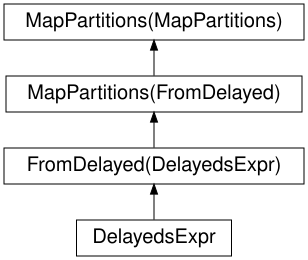

In [11]:
new_df = df.map_partitions(compute_coordinates)
new_df.visualize(filename="graph.png")

#new_df.columns = [str(c) for c in new_df.columns]
#new_df.visualize(filename="transpose_opt.svg", optimize_graph=True)

In [12]:
%%time
new_df.compute()

CPU times: user 18.3 ms, sys: 7.51 ms, total: 25.8 ms
Wall time: 2.58 s


,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666,-42.0,1800.3,27,0,1.832787,-40.167213,-43.832787
1,0,107,1118948,882,8,1,101.4,9.969829e+10,9.969829e+10,127.233337,126.0,957.8,43,0,6.845154,132.845154,119.154846
2,1,47,1118948,881,18,2,95.5,9.969829e+10,9.969829e+10,104.666672,168.0,1016.1,47,0,5.631067,173.631067,162.368933
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666,-63.0,1839.3,24,3,9.230287,-53.769713,-72.230287
4,1,44,1118948,881,14,2,95.5,9.969829e+10,9.969829e+10,101.333344,147.0,1055.1,44,3,5.451734,152.451734,141.548266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7659,0,108,48580108,3047,25,1,101.4,4.328488e+12,4.328488e+12,282.233398,147.0,996.8,44,3,15.184157,162.184157,131.815843
7660,0,105,48580108,3048,22,1,101.4,4.328488e+12,4.328488e+12,304.733398,105.0,970.8,41,1,16.394657,121.394657,88.605343
7661,1,40,48580108,3046,13,2,95.5,4.328488e+12,4.328488e+12,241.333008,105.0,1055.1,40,3,12.983716,117.983716,92.016284
7662,1,38,48580108,3047,1,2,95.5,4.328488e+12,4.328488e+12,256.333008,84.0,1042.1,38,2,13.790716,97.790716,70.209284


In [ ]:
# persist results to continue
new_df.persist()

<Axes: >

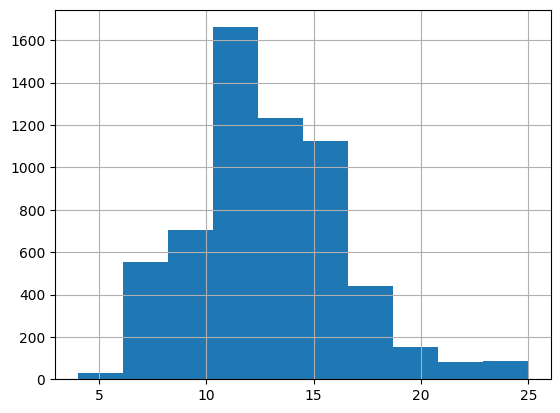

In [14]:
df.groupby("ORBIT").size().compute().hist()

## Local fit plot (prova)

In [18]:
# per fare le prove con diverse orbite
unique_orbits = df["ORBIT"].unique().compute()
print(unique_orbits)

0       1144838
1       1150842
2       1247112
3       1252229
4       1339251
         ...   
587    48519213
588    48520227
589    48545828
590    48569403
591    48576415
Name: ORBIT, Length: 6069, dtype: uint64


In [19]:
# per prova considero il primo valore di orbit
orbit_id = df["ORBIT"].head(1).iloc[0]
print(f"Selected orbit: {orbit_id}")

# filtro per l'orbita in questione
df_evt = df[df["ORBIT"] == 1118948].compute()
df_evt

Selected orbit: 1118948


,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666
1,0,107,1118948,882,8,1,101.4,9.969829e+10,9.969829e+10,127.233337
2,1,47,1118948,881,18,2,95.5,9.969829e+10,9.969829e+10,104.666672
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666
4,1,44,1118948,881,14,2,95.5,9.969829e+10,9.969829e+10,101.333344
5,1,90,1118948,883,17,3,92.4,9.969829e+10,9.969829e+10,150.733337
6,1,46,1118948,887,5,2,95.5,9.969829e+10,9.969829e+10,243.833328
7,1,89,1118948,889,12,3,92.4,9.969829e+10,9.969829e+10,296.566666
8,0,105,1118948,890,20,1,101.4,9.969829e+10,9.969829e+10,337.233322
9,0,108,1118948,891,13,1,101.4,9.969829e+10,9.969829e+10,356.399994


Per questo plot locale non ho usato la vera coordinata z ma una coordinata "fittizia" y per comodità (nel plot globale converrà usare la z).

In [20]:
def plot_chamber_hits(df_evt, chamber_id=3):
    # filters the selected chamber
    df_ch = df_evt[df_evt["CHAMBER"] == chamber_id]
    
    n_layers = 4
    n_cells = 16
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w/2
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # for the cells
    for layer in range(n_layers):
        # offset for odd layers
        x_offset = 0 if layer % 2 == 0 else offset
        for cell in range(n_cells):
            x0 = (cell*cell_w) - (n_cells*cell_w)/2 + x_offset
            y0 = (n_layers - layer - 1) * cell_h
            rect = patches.Rectangle(
                (x0, y0),
                cell_w, cell_h,
                linewidth=2, edgecolor="gray", facecolor="none")
            ax.add_patch(rect)
            
    layer_order = {0: 0, 2: 1, 1: 2, 3: 3} # mapping for the y (1-2 are inverted)
    y_pos = (n_layers-1 - df_ch["layer"].map(layer_order))

    ax.scatter(df_ch["x"], 
               y_pos*cell_h + cell_h/2,
               color="red", s=2, zorder=3, label="Center")
    
    ax.scatter(df_ch["X_LEFT"], 
               y_pos*cell_h + cell_h/2,
               color="blue", s=2, marker='x', zorder=3, label="Left")
    
    ax.scatter(df_ch["X_RIGHT"], 
               y_pos*cell_h + cell_h / 2,
               color="green", s=2, marker='x', zorder=3, label="Right")

    ax.set_aspect('equal')
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("")
    ax.set_title(f"Chamber {chamber_id}")
    #ax.legend()
    plt.show()

KeyError: 'layer'

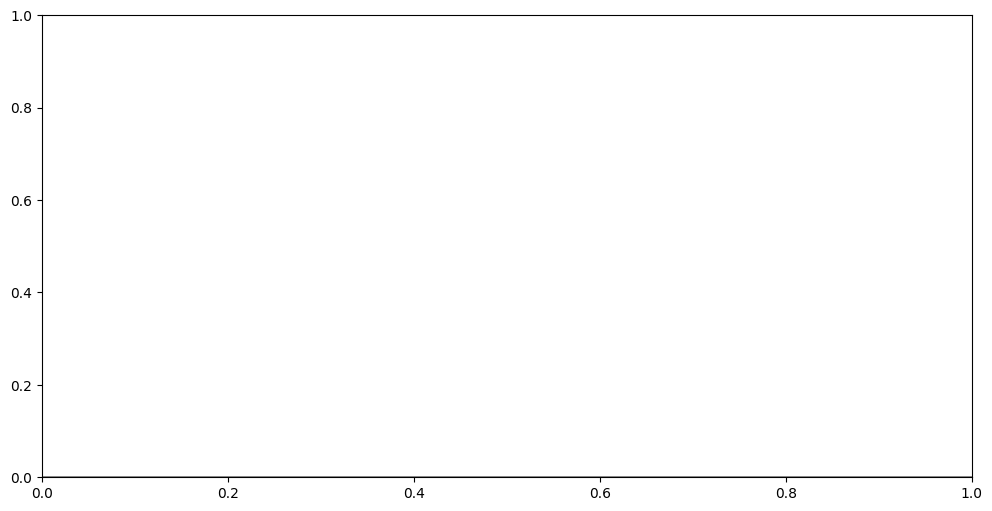

In [21]:
plot_chamber_hits(df_evt, chamber_id=3)

In [ ]:
plot_chamber_hits(df_evt, chamber_id=2)

In [ ]:
plot_chamber_hits(df_evt, chamber_id=1)

In [ ]:
plot_chamber_hits(df_evt, chamber_id=0)

## Prova del fit locale - prova

In [ ]:
def fit_local_geom(df_evt, chamber_id=3, cell_h=13.0):
    df_ch = df_evt[df_evt["CHAMBER"] == chamber_id].copy()
    if len(df_ch) < 3:
        return None

    layer_order = {0: 0, 2: 1, 1: 2, 3: 3}
    y_pos = (3 - df_ch["layer"].map(layer_order))
    y_vals = y_pos.values*cell_h + cell_h/2.0
    
    x_left  = df_ch["X_LEFT"].values
    x_right = df_ch["X_RIGHT"].values

    best = {"resid": np.inf}
    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        resid = np.sum((x_vals - (m*y_vals + q))**2)
        
        if resid < best["resid"]:
            best = {
                "m": m, "q": q, "resid": resid,
                "x_best": x_vals.copy(), "y_vals": y_vals.copy()}
    return best

In [ ]:
def fit_chamber_hits(df_evt, chamber_id=3):
    # filters the selected chamber
    df_ch = df_evt[df_evt["CHAMBER"] == chamber_id]
    
    n_layers = 4
    n_cells = 16
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # for the cells
    for layer in range(n_layers):
        # offset for odd layers
        x_offset = 0 if layer % 2 == 0 else offset
        for cell in range(n_cells):
            x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + x_offset
            y0 = (n_layers - layer - 1) * cell_h
            rect = patches.Rectangle(
                (x0, y0),
                cell_w, cell_h,
                linewidth=2, edgecolor="gray", facecolor="none"
            )
            ax.add_patch(rect)
            
    layer_order = {0: 0, 2: 1, 1: 2, 3: 3} # mapping for the y (1-2 are inverted)
    y_pos = (n_layers - 1 - df_ch["layer"].map(layer_order))

    ax.scatter(df_ch["x"], 
               y_pos * cell_h + cell_h / 2,
               color="red", s=2, zorder=3, label="Center")
    
    ax.scatter(df_ch["X_LEFT"], 
               y_pos * cell_h + cell_h / 2,
               color="blue", s=2, marker='x', zorder=3, label="Left")
    
    ax.scatter(df_ch["X_RIGHT"], 
               y_pos * cell_h + cell_h / 2,
               color="green", s=2, marker='x', zorder=3, label="Right")
    res = fit_local_geom(df_evt, chamber_id=3)
    if res is not None:
        m, q = res["m"], res["q"]
        y_line = np.linspace(0, 4*cell_h, 100)
        x_line = m*y_line + q
        ax.plot(x_line, y_line, color="black", linewidth=2, label="Fit")


    ax.set_aspect('equal')
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("")
    ax.set_title(f"Chamber {chamber_id}")
    #ax.legend()
    plt.show()

In [ ]:
fit_chamber_hits(df_evt, chamber_id=3)

# Due metodi per generalizzare (groupby+apply e group_by+map_partition )

## Versione senza chi2

### Groupby+apply

In [ ]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3}

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values

    best = {"resid": np.inf}
    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        resid = np.sum((x_vals - (m*y_vals + q))**2)
        if resid < best["resid"]:
            best = {"m": m, "q": q, "resid": resid}

    return pd.Series(best)



In [ ]:
df_fits_1 = (
    new_df.groupby(["ORBIT", "CHAMBER"])
    .apply(fit_local_geom_pandas)#, meta={"m": "f8", "q": "f8", "resid": "f8"})
)

In [ ]:
%%time
df_fits_1.compute()


### map_partitions+groupby

In [ ]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3}

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values

    best = {"resid": np.inf}
    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        resid = np.sum((x_vals - (m*y_vals + q))**2)
        if resid < best["resid"]:
            best = {"m": m, "q": q, "resid": resid}

    return pd.Series(best)


def fit_partition(df, cell_h=13.0):
    results = []
    for (orbit, chamber), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        res = fit_local_geom_pandas(df_grp, cell_h=cell_h)
        res["ORBIT"] = orbit  
        res["CHAMBER"] = chamber  
        results.append(res)
    
    df_out = pd.DataFrame(results)
    return df_out.set_index(["ORBIT", "CHAMBER"])


In [ ]:
df_fits_2 = new_df.map_partitions(
    fit_partition, 
    meta={"m": "f8", "q": "f8", "resid": "f8"}
)


In [ ]:
%%time
df_fits_2.compute()


## Versione con Chi2

### Groupby+apply

In [ ]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3} ###porto fuori perchè dentro non serve e sembra più veloce

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan, "χ²/ndof": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values
    sigma=1
    best = {"resid": np.inf, "χ²/ndof": np.inf}

    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        
        residuals = (x_vals - (m*y_vals + q))**2
        resid = np.sum(residuals) ####  sum here so I can use residuals in chi2 without "breaking up" the sum
        chi2 = np.sum((residuals / sigma))  ##already squared
        ndof = len(x_vals) - 2  # 2=number of parameters of linear fit

        if chi2/ndof < best["χ²/ndof"]:
            best = {"m": m, "q": q, "resid": resid, "χ²/ndof": chi2/ndof}

    return pd.Series(best)
df_fits_1 = (
    new_df.groupby(["ORBIT", "CHAMBER"])
    .apply(fit_local_geom_pandas)#, meta={"m": "f8", "q": "f8", "resid": "f8"})
)


In [ ]:
%%time
df_fits_1.compute()

### map_partitions+groupby

In [ ]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3} ###porto fuori perchè dentro non serve e sembra più veloce

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values

    best = {"resid": np.inf, "χ²/ndof": np.inf}

    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        sigma=1
        residuals = (x_vals - (m*y_vals + q))**2
        resid = np.sum(residuals) ####  sum here so I can use residuals in chi2 without "breaking up" the sum
        chi2 = np.sum((residuals / sigma))  ##already squared
        ndof = len(x_vals) - 2  # 2=number of parameters of linear fit

        if chi2/ndof < best["χ²/ndof"]:
            best = {"m": m, "q": q, "resid": resid, "χ²/ndof": chi2/ndof}
    return pd.Series(best)


def fit_partition(df, cell_h=13.0):
    results = []
        for (orbit, chamber), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        res = fit_local_geom_pandas(df_grp, cell_h=cell_h)
        res["ORBIT"] = orbit  
        res["CHAMBER"] = chamber  
        results.append(res)
    
    df_out = pd.DataFrame(results)
    return df_out.set_index(["ORBIT", "CHAMBER"])
    
df_fits_2 = new_df.map_partitions(
    fit_partition, 
    meta={"m": "f8", "q": "f8", "resid": "f8","": "f8"}
)
    

In [ ]:
%%time
df_fits_2.compute()

## Local fit (without explicit for loop)

In [39]:
def fit_chamber_vectorized(df_ch):
    if len(df_ch) < 3:
        return None
    
    x_left = df_ch["X_LEFT"].values
    x_right = df_ch["X_RIGHT"].values
    z_vals = df_ch["z"].values
    N = len(x_left)

    # generate all left/right combinations (2^N x N)
    choices = np.array(list(itertools.product([0, 1], repeat=N)))
    
    # create candidate x positions for each combination
    x_matrix = np.where(choices == 0, x_left, x_right)  # shape (2^N, N)

    # fit lines and compute residuals in vectorized form
    
    z_matrix = np.tile(z_vals, (2**N, 1))  # repeat y_vals for each combination

    # linear regression by hand: x = m*y + q
    z_mean = z_matrix.mean(axis=1)
    x_mean = x_matrix.mean(axis=1)
    m = np.sum((z_matrix - z_mean[:, None]) * (x_matrix - x_mean[:, None]), axis=1) / np.sum((z_matrix - z_mean[:, None])**2, axis=1)
    q = x_mean - m * z_mean
    resid = np.sum((x_matrix - (m[:, None]*z_matrix + q[:, None]))**2, axis=1)
  
    N = z_vals.shape[0]       # number of hits
    ndof = max(N-2, 1)        # degrees of freedom (avoid div by 0)
    chi_sq = resid /ndof

    best_idx = np.argmin(chi_sq)
    best = {
    "m": m[best_idx],
    "q": q[best_idx],
    "χ²/ndof": chi_sq[best_idx],
    "x_best": x_matrix[best_idx],
    "z_vals": z_vals}
    
    return best


import dask.dataframe as dd

def process_partition(df):
    results = []
    for (orbit, chamber_id), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        best = fit_chamber_vectorized(df_grp)
        if best is not None:
            results.append({
                "ORBIT": orbit,
                "CHAMBER": chamber_id,
                "m": best["m"],
                "q": best["q"],
                "χ²/ndof": best["χ²/ndof"],
                "x_best": best["x_best"],
                "z_vals": best["z_vals"]} )
            
    return pd.DataFrame(results)


 # we need to explicitly tell Dask what the output schema of the df will be

meta = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "CHAMBER": pd.Series(dtype="int64"),
    "m": pd.Series(dtype="float64"),
    "q": pd.Series(dtype="float64"),
    "χ²/ndof": pd.Series(dtype="float64"),
    "x_best": pd.Series(dtype="object"),  # lists/arrays stored as objects
    "z_vals": pd.Series(dtype="object")
})
    

In [112]:
df_local_fit= new_df.map_partitions(process_partition,meta=meta)

In [113]:
%%time
# compute local fits for all orbits and all chambers 
fit_results = df_local_fit.compute()
fit_results

CPU times: user 47.8 ms, sys: 8.11 ms, total: 55.9 ms
Wall time: 5.33 s


,ORBIT,CHAMBER,m,q,χ²/ndof,x_best,z_vals
0,1118948,1,0.216296,-87.542832,0.775071,"[119.15484644775391, 123.14315273132324, 127.8...","[957.8, 970.8, 996.8]"
1,1118948,2,-0.267759,434.702037,0.690165,"[162.36893305969238, 152.45173388061522, 154.8...","[1016.0999999999999, 1055.1, 1042.1, 1029.1]"
2,1118948,3,-0.252889,411.517542,0.038916,"[-43.832786611938474, -53.769713388061525, -50...","[1800.3, 1839.3, 1826.3, 1813.3]"
3,1123056,0,0.130101,95.628744,0.667026,"[124.44517950744628, 121.30684726867676, 124.2...","[226.3, 200.3, 213.3, 239.3]"
4,1123056,1,0.427381,-255.825622,0.542577,"[164.47251338806151, 159.94248661193848, 152.9...","[983.8, 970.8, 957.8, 996.8]"
...,...,...,...,...,...,...,...
1755,48576415,1,-0.046563,135.055653,65.745969,"[85.46513056640624, 91.06931474609375, 80.6499...","[983.8, 957.8, 970.8, 970.8, 983.8, 996.8]"
1756,48576415,2,-0.262656,375.795920,0.086336,"[105.5649, 98.8757841796875, 101.7360579101562...","[1029.1, 1055.1, 1042.1, 1016.0999999999999]"
1757,48576415,3,-0.234706,339.878673,0.492665,"[-82.83975361328125, -87.93993056640625, -92.3...","[1800.3, 1826.3, 1839.3, 1813.3]"
1758,48580108,1,0.247827,-116.212181,13.844290,"[123.14502734375, 131.8158431640625, 121.39465...","[957.8, 996.8, 970.8]"


In [ ]:
df_local_fit.persist()

In [85]:
def plot_fit_chamber_hits(df_evt,orbit_id,chamber_id=3):
    # filters the selected chamber
    df_ch = df_evt[(df_evt["CHAMBER"] == chamber_id) & (df_evt["ORBIT"] == orbit_id)].compute()
    
    fig= plt.figure(figsize=(8, 6))
    
            
    plt.scatter(df_ch["x"], 
               df_ch["z"],
               color="red",label="Center")
    
    plt.scatter(df_ch["X_LEFT"], 
               df_ch["z"],
               color="blue",label="Left")
    
    plt.scatter(df_ch["X_RIGHT"], 
                df_ch["z"],
               color="green", label="Right")
    
    fit = fit_chamber_vectorized(df_ch)
    if fit is not None:
        m, q = fit["m"], fit["q"]
        z_line = np.linspace(df_ch["z"].min(), df_ch["z"].max(), 100)
        x_line = m*z_line + q
        plt.plot(x_line, z_line, color="black", linewidth=1.5,linestyle='--',label=f"Best fit (χ²/ndof = {round(fit['χ²/ndof'],2)})")

    plt.xlabel("x [mm]")
    plt.ylabel("")
    plt.title(f"Orbit: {orbit_id},Chamber {chamber_id}")
    plt.legend()
    #ax.legend()
    plt.show()

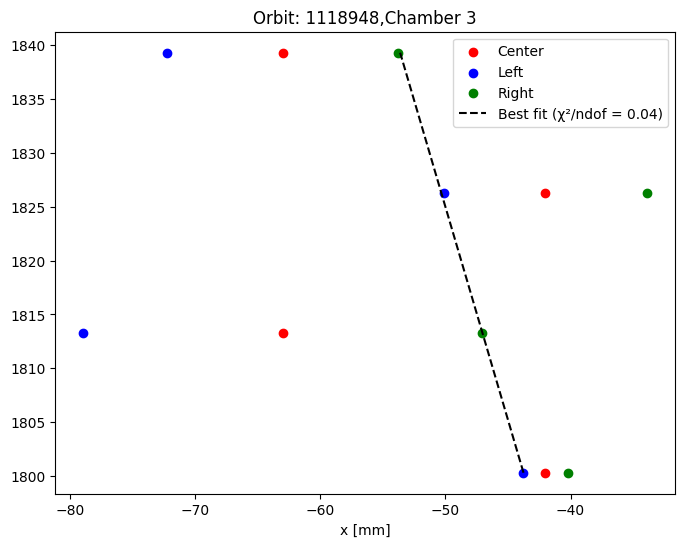

In [86]:
plot_fit_chamber_hits(new_df,orbit_id=1118948,chamber_id=3)

In [91]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_fit_chamber_hits(df_evt, orbit_id, chamber_id=3):
    # filtra la camera selezionata
    df_ch = df_evt[(df_evt["CHAMBER"] == chamber_id) & (df_evt["ORBIT"] == orbit_id)].compute()
    
    n_layers = 4
    n_cells = 16
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    z_min = df_ch["z"].min()-cell_h/2 ## fix the base of the grid to minimum z-half cell (to center points in the cell along z)
    
    # disegna le celle
    for layer in range(n_layers):
        x_offset = 0 if layer % 2 == 0 else -offset
        for cell in range(n_cells):
            x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + cell_w/2 + x_offset ## x_offset è diverso da cell_w/2 perchè è oscillante 
            z0 = z_min + layer*cell_h  
            rect = patches.Rectangle(
                (x0, z0),
                cell_w, cell_h,
                linewidth=1, edgecolor="gray", facecolor="none"
            )
            ax.add_patch(rect)
    
    # hit
    ax.scatter(df_ch["x"], df_ch["z"], color="red", label="Center")
    ax.scatter(df_ch["X_LEFT"], df_ch["z"], color="blue", label="Left")
    ax.scatter(df_ch["X_RIGHT"], df_ch["z"], color="green", label="Right")
    
    # fit
    fit = fit_chamber_vectorized(df_ch)
    if fit is not None:
        m, q = fit["m"], fit["q"]
        z_line = np.linspace(df_ch["z"].min(), df_ch["z"].max(), 200)
        x_line = m * z_line + q
        ax.plot(x_line, z_line, color="black", linewidth=1.5,label="Best fit")
    
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [mm]")
    ax.set_title(f"Orbit: {orbit_id}, Chamber {chamber_id}")
    ax.legend()
    ax.set_aspect("equal")
    #ax.set_xlim(-150, 50) 
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.savefig('foo.png')
    plt.show()


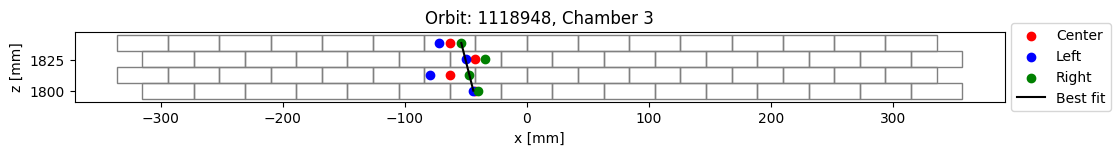

In [92]:
plot_fit_chamber_hits(new_df,orbit_id=1118948,chamber_id=3)

In [22]:
new_df[(new_df["CHAMBER"] == 3) & (new_df["ORBIT"] == 1118948)].compute()

,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666,-42.0,1800.3,27,0,1.832787,-40.167213,-43.832787
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666,-63.0,1839.3,24,3,9.230287,-53.769713,-72.230287
5,1,90,1118948,883,17,3,92.4,9.969829e+10,9.969829e+10,150.733337,-42.0,1826.3,26,2,8.109454,-33.890546,-50.109454
7,1,89,1118948,889,12,3,92.4,9.969829e+10,9.969829e+10,296.566666,-63.0,1813.3,25,1,15.955287,-47.044713,-78.955287


In [24]:
fit_results[(fit_results["CHAMBER"] == 3) & (fit_results["ORBIT"] == 1118948)]

,ORBIT,CHAMBER,m,q,χ²/ndof,x_best,z_vals
2,1118948,3,-0.252889,411.517542,0.038916,"[-43.832786611938474, -53.769713388061525, -50...","[1800.3, 1839.3, 1826.3, 1813.3]"


### Global track fit

In [36]:
def fit_global(df_orbit):
    """
    df_orbit: DataFrame with local fit results for chambers 0,2,3
              and a single ORBIT.
              It needs to contain columns 'CHAMBER', 'x_best', 'z_vals'. """
    # Consider only chambers 0,2,3
    df_sel = df_orbit[df_orbit["CHAMBER"].isin([0,2,3])]
    if len(df_sel) < 2:
        return None  # troppo poche camere per un fit globale

    # Concatenate all x_best e z_vals of 
    x_all = np.concatenate(df_sel["x_best"].values)
    z_all = np.concatenate(df_sel["z_vals"].values)
    
    # Global linear fit (least squares)
    z_mean = np.mean(z_all)
    x_mean = np.mean(x_all)
    
    m = np.sum((z_all - z_mean)*(x_all - x_mean))/np.sum((z_all - z_mean)**2)
    q = x_mean - m*z_mean
    
    resid = np.sum((x_all - (m*z_all + q))**2)
    ndof = len(x_all)-2
    chi_sq = resid / ndof
    
    return {
        "m_global": m,
        "q_global": q,
        "χ²/ndof_global": chi_sq,
        "x_all": x_all,
        "z_all": z_all
    }

def process_partition_global(df_fit_local):
    results = []
    for orbit, df_grp in df_fit_local.groupby("ORBIT"):
        df_pass = df_grp[["CHAMBER", "x_best", "z_vals"]]
        best_global = fit_global(df_pass)
        if best_global is not None:
            results.append({
                "ORBIT": orbit,
                **best_global })
    return pd.DataFrame(results)

# Schema Dask per il fit globale
meta_global = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "m_global": pd.Series(dtype="float64"),
    "q_global": pd.Series(dtype="float64"),
    "χ²/ndof_global": pd.Series(dtype="float64"),
    "x_all": pd.Series(dtype="object"),
    "z_all": pd.Series(dtype="object")
})


In [115]:
df_global_fit= df_local_fit.map_partitions(process_partition_global,meta=meta_global)

In [116]:
%%time
# global fit for all orbits
global_fit_results = df_global_fit.compute()
global_fit_results

CPU times: user 29 ms, sys: 0 ns, total: 29 ms
Wall time: 6.45 s


,ORBIT,m_global,q_global,χ²/ndof_global,x_all,z_all
0,1118948,-0.262812,429.576638,0.260344,"[162.36893305969238, 152.45173388061522, 154.8...","[1016.0999999999999, 1055.1, 1042.1, 1029.1, 1..."
1,1123056,0.077788,107.109373,0.759312,"[124.44517950744628, 121.30684726867676, 124.2...","[226.3, 200.3, 213.3, 239.3, 1055.1, 1029.1, 1..."
2,1124284,-0.057558,148.519193,0.313131,"[89.00340082092285, 90.70706694030761, 87.4432...","[1042.1, 1016.0999999999999, 1055.1, 1029.1, 1..."
3,1126947,0.091026,21.586312,0.521112,"[115.42823305969239, 116.2891, 118.2079, 113.5...","[1029.1, 1042.1, 1055.1, 1016.0999999999999, 1..."
4,1130581,0.199468,-45.754901,102.047356,"[167.7041, 151.55506694030763, 162.3241, 160.8...","[1042.1, 1029.1, 1016.0999999999999, 1055.1, 1..."
...,...,...,...,...,...,...
444,48559795,0.099982,30.982830,2.039502,"[50.9971568359375, 53.15100107421875, 53.91131...","[200.3, 239.3, 226.3, 213.3, 1042.1, 1016.0999..."
445,48560150,0.212607,-54.569361,415.031614,"[-29.1901568359375, -13.25631474609375, 18.950...","[239.3, 226.3, 200.3, 1016.0999999999999, 1029..."
446,48569403,0.310180,-156.300971,0.540399,"[-86.227341015625, -94.3421568359375, -90.2193...","[226.3, 200.3, 213.3, 239.3, 1042.1, 1016.0999..."
447,48570850,0.230943,-64.775562,1.389592,"[-12.8976568359375, -8.55068525390625, -19.129...","[226.3, 239.3, 200.3, 1016.0999999999999, 1042..."


In [ ]:
df_global_fit.persist()

### Global fit plots

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

def plot_fit_global_hits_with_detector(df_evt, orbit_id):
    # Filtra l'orbit scelto
    df_ch = df_evt[df_evt["ORBIT"] == orbit_id].compute()
    if df_ch.empty:
        print(f"No global fit found for ORBIT={orbit_id}")
        return
    
    # Prendo la prima (e unica) riga
    row = df_ch.iloc[0]
    m, q = row["m_global"], row["q_global"]
    z_all, x_all = row["z_all"], row["x_all"]   # array numpy
    chi_sq= row["χ²/ndof_global"]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Parametri geometrici reali del rivelatore
    shift_chamber = {
        0: {'x': 0, 'y': 0, 'z': 219.8},  # Ch 0
        1: {'x': 0, 'y': 0, 'z': 977.3},  # Ch 1
        2: {'x': 0, 'y': 0, 'z': 1035.6}, # Ch 2
        3: {'x': 0, 'y': 0, 'z': 1819.8}, # Ch 3
    }
    
    # Parametri geometrici
    n_layers = 4
    n_cells = 16
    n_chambers = 4 
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    # Dimensioni totali delle camere
    chamber_width = n_cells * cell_w  # 16 * 42 = 672 mm
    chamber_height = n_layers * cell_h  # 4 * 13 = 52 mm
    
    # Disegna le camere del rivelatore
    #colors = ['lightgray', 'lightblue', 'lightgreen', 'lightyellow']
    
    z_min = z_all.min() - cell_h/2  # ancora la base della griglia al minimo z-metà cella
    
    for chamber in range(n_chambers):  
        ch_name = f'Ch {chamber}'
        z_pos = shift_chamber[chamber]['z']

        if ch_name == 'Ch 1':
            ## Rettangolo della camera 1
            chamber = patches.Rectangle(
                (-chamber_width/2, z_pos - chamber_height/2),
                chamber_width+cell_w/2, chamber_height,
                linewidth=1, edgecolor='black', facecolor='none'
            )
            ax.add_patch(chamber)
            
            # Numero di linee orizzontali
            num_lines = 4
            y_positions = np.linspace(z_pos - chamber_height/2, z_pos + chamber_height/2, num_lines+2)[1:-1]
            
            for y in y_positions:
                ax.hlines(y, -chamber_width/2, chamber_width/2+cell_w/2, colors='grey', linewidth=0.8)
        else:
            # Griglia delle celle usando il pattern specificato
            for layer in range(n_layers):
                x_offset = 0 if layer % 2 == 0 else -offset
                for cell in range(n_cells):
                    x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + cell_w/2 + x_offset
                    z0 = (z_pos + layer * cell_h)-chamber_height/2
                    rect = patches.Rectangle(
                        (x0, z0),
                        cell_w, cell_h,
                        linewidth=1, edgecolor="gray", facecolor="none"
                    )
                    ax.add_patch(rect)
        
        # Etichetta della camera
        ax.text(-chamber_width/2 - 30, z_pos, ch_name, 
                horizontalalignment='center', fontsize=10, fontweight='bold')
        
    
    # Scatter delle hit (sovrapposto alle camere)
    ax.scatter(x_all, z_all, color="red", s=50, zorder=10, 
               label="Hits", edgecolors='darkred', linewidth=1)
    
    # Retta del fit globale
    z_line = np.linspace(z_all.min() - 50, z_all.max() + 50, 100)
    x_line = m * z_line + q
    ax.plot(x_line, z_line, color="red", linewidth=2, 
            label=f"Fit globale (χ²/dof={round(chi_sq,2)})", zorder=9, linestyle='--')
    
    # Miglioramenti estetici
    ax.set_xlabel("x [mm]", fontsize=12)
    ax.set_ylabel("z [mm]", fontsize=12)
    ax.set_title(f"Globale track Fit - Orbit: {orbit_id}", fontsize=14, fontweight='bold')
    ax.legend(loc='best', bbox_to_anchor=(0.95, 0.9))
    #ax.grid(True, alpha=0.3)
    
    # Imposta i limiti degli assi
    z_min = min([shift_chamber[i]['z'] for i in range(4)]) - 100
    z_max = max([shift_chamber[i]['z'] for i in range(4)]) + 100
    ax.set_xlim(-chamber_width/2 - 50, chamber_width/2 + 50)
    ax.set_ylim(z_min, z_max)
    
    #ax.set_xlim(190,250)
    #ax.set_ylim(1790,1870)

    plt.tight_layout()
    plt.show()


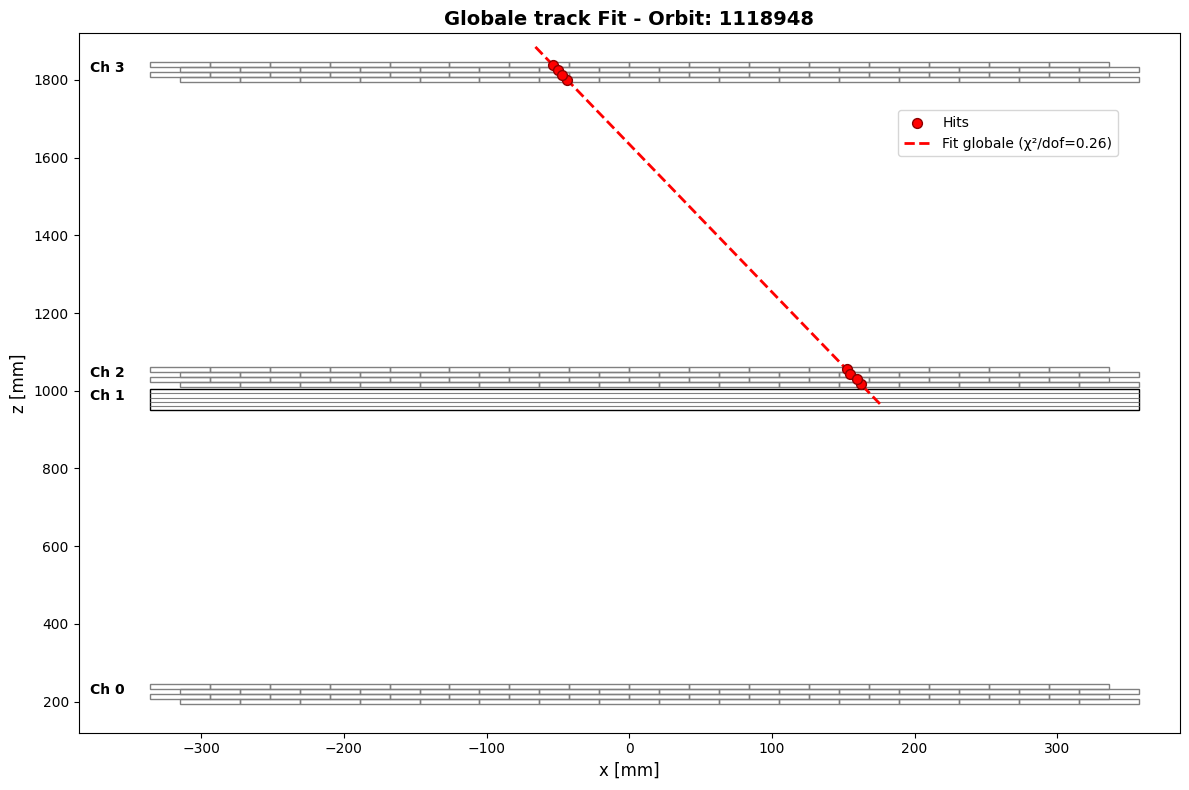

In [84]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=1118948)

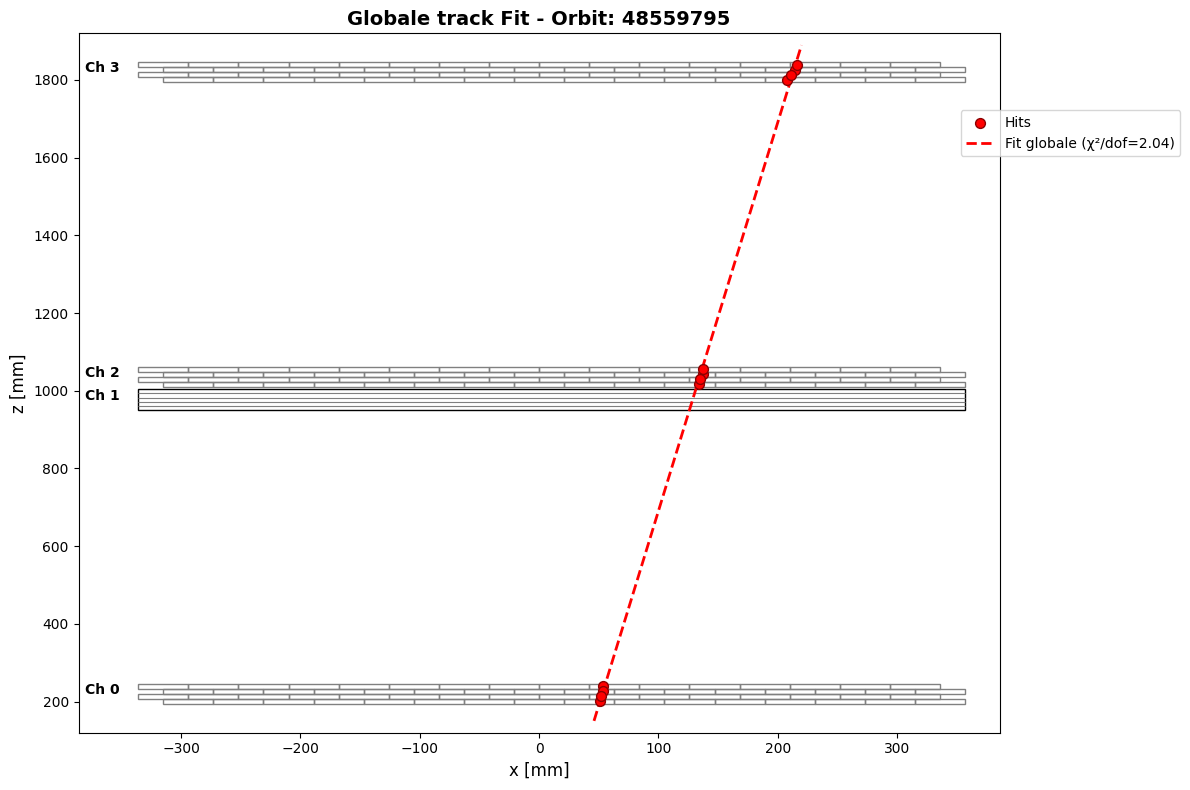

In [93]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=48559795)

Some orbits appear to be clealry problematic: these signals could be uncorrelated background noise or signals from two different muons crossing the chambers in the same orbit.     

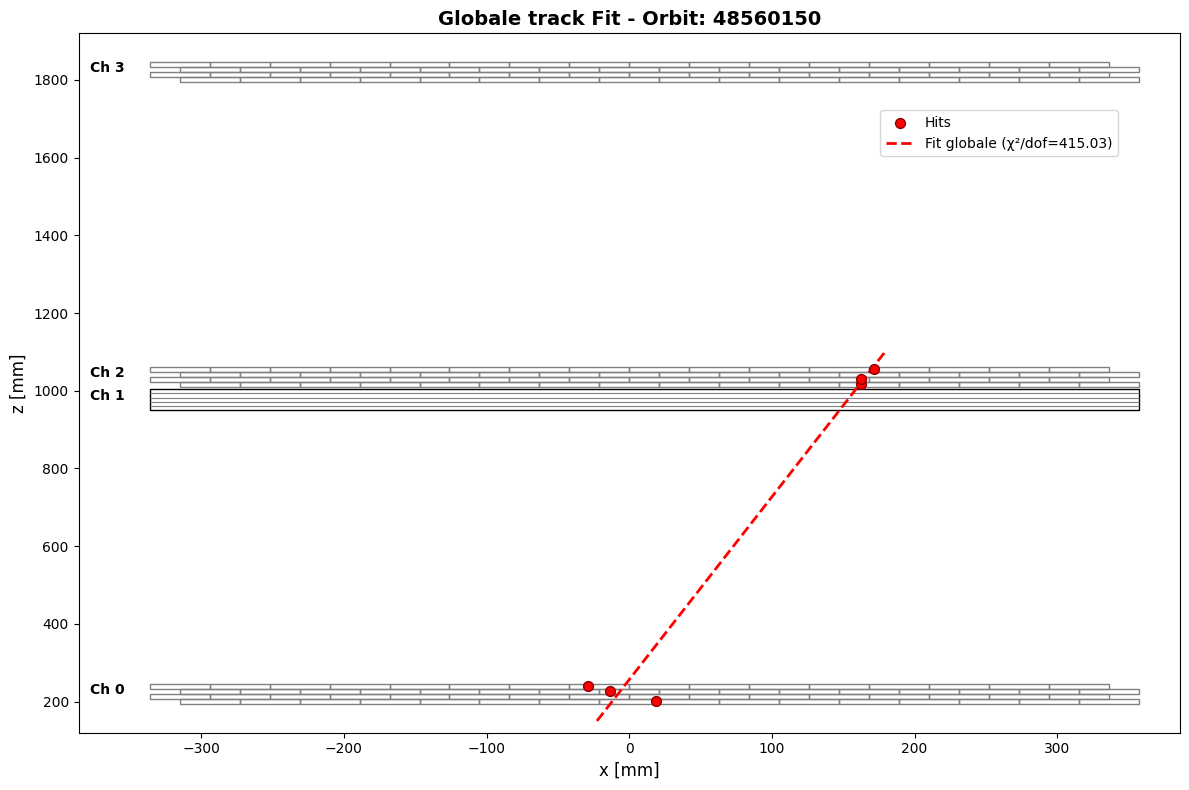

In [68]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=48560150)

## Single detector angular resolution

We compute the angular difference between the global track fit and the locaal track fit of Chamber 2, considering only events with a resonable $\chi^2$ value (discarding probable noise and errors in the track computation). The mean value of the absolute angular differences across all events gives an estimate of the detector angular resolution. 

The reduced $\chi^2$ with N degrees of freedom has an expected value of 1, with standard deviation $\sigma=\sqrt{2/N}$. Considering in our case we have at most N=10, then $\sigma \approx 0.45$. We have around 5000 reconstruceted events (orbits), therefore we are not expecting any event with a reduced $\chi^2$ more than 4$\sigma\approx 1.8$ away from unity. We consider these events as errors and discard them in the angular resolution estimate.  

In [136]:
fit_results_2 = fit_results[fit_results['CHAMBER']==2]

# merge the local and global fit results on common orbits
merged = fit_results_2.merge(
    global_fit_results,
    on="ORBIT",
    how="inner")

compare_results = merged[merged['χ²/ndof_global'] < 2.8]


ang_diff = compare_results.copy()
ang_diff['ang_diff'] = np.degrees(np.arctan((ang_diff["m"] - ang_diff["m_global"])))
ang_diff= ang_diff[['ORBIT','χ²/ndof_global','m','m_global','ang_diff']]
ang_diff

,ORBIT,χ²/ndof_global,m,m_global,ang_diff
0,1118948,0.260344,-0.267759,-0.262812,-0.283492
1,1123056,0.759312,0.094841,0.077788,0.976981
2,1124284,0.313131,-0.071249,-0.057558,-0.784409
3,1126947,0.521112,0.114014,0.091026,1.316880
5,1135298,0.165135,0.336941,0.337672,-0.041869
...,...,...,...,...,...
4575,48558325,0.192869,-0.146571,-0.142676,-0.223151
4576,48559795,2.039502,0.092908,0.099982,-0.405311
4578,48569403,0.540399,0.362600,0.310180,3.000686
4579,48570850,1.389592,0.162918,0.230943,-3.891522


In [138]:
ang_res = np.abs(ang_diff['ang_diff']).mean()
err = ang_diff['ang_diff'].std()/len(ang_diff)**0.5
print(f"Our estimate for the angular resolution of the single detector is {ang_res:.2f}° +- {err:.2f}°")

Our estimate for the angular resolution of the single detector is 1.04° +- 0.03°


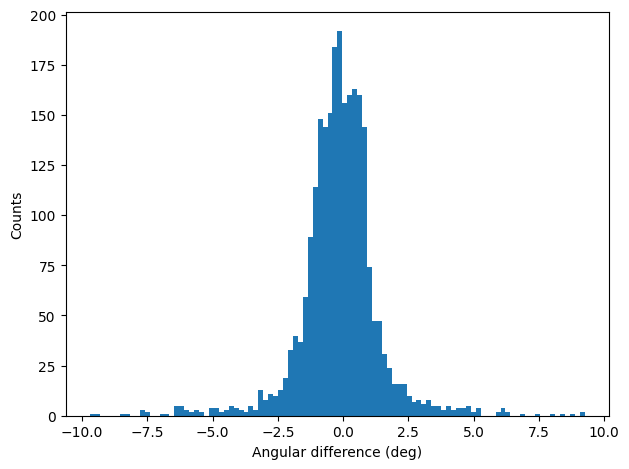

In [142]:
plt.hist(ang_diff['ang_diff'],bins=100)
plt.xlabel('Angular difference (deg)')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()